# CIFAR-10 Image Classification with Fully Connected Networks

**CSCI 394 - Spring 2026 Tutorial**

In this tutorial, we move beyond MNIST to tackle a more challenging image classification task: **CIFAR-10**. We will use a fully connected (dense) neural network and observe its limitations on color images, motivating the use of Convolutional Neural Networks (CNNs) in the next tutorial.

## What you will learn

1. How CIFAR-10 differs from MNIST and why it is harder
2. How to handle color (RGB) images in PyTorch
3. The importance of data normalization for training stability
4. Why fully connected networks struggle with natural images
5. How to interpret and debug model performance

## Background: The CIFAR-10 Dataset

CIFAR-10 (Canadian Institute For Advanced Research) is a widely used benchmark dataset containing:

- **50,000 training images** and **10,000 test images**
- Each image is **32x32 pixels** with **3 color channels** (RGB)
- **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

### Why is CIFAR-10 harder than MNIST?

| Feature | MNIST | CIFAR-10 |
|---------|-------|----------|
| Image size | 28x28 | 32x32 |
| Channels | 1 (grayscale) | 3 (RGB) |
| Content | Centered digits | Natural scenes |
| Variability | Low (handwriting) | High (pose, lighting, background) |
| Input features | 784 | 3,072 |
| Best FC accuracy | ~98% | ~55-60% |
| Best CNN accuracy | >99.7% | >96% |

## Step 0: Setup (Google Colab)

If running on Google Colab, enable GPU: `Runtime > Change runtime type > GPU`.

In [1]:
# Install dependencies (only needed if not on Colab)
# !pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

print(f"PyTorch version: {torch.__version__}")

# Select device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

PyTorch version: 2.10.0
Using Apple MPS
Device: mps


## Step 1: Load and Explore CIFAR-10

### Data Normalization

Unlike MNIST where we only converted to tensors, for CIFAR-10 we also **normalize** the pixel values. Normalization shifts the data to have zero mean and unit variance per channel, which helps training converge faster and more reliably.

The mean and standard deviation values below are pre-computed statistics from the CIFAR-10 training set:
- Mean: (0.4914, 0.4822, 0.4465) for R, G, B channels
- Std:  (0.2470, 0.2435, 0.2616) for R, G, B channels

After normalization, each channel will have approximately zero mean and unit variance.

In [2]:
# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
SEED = 42

torch.manual_seed(SEED)

# CIFAR-10 class names
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Data transforms
# For training: normalize to help convergence
# For testing: same normalization (must match training)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2470, 0.2435, 0.2616)),
])

# Download and load CIFAR-10
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}  (channels x height x width)")
print(f"Number of classes: {len(CLASS_NAMES)}")
print(f"Classes: {CLASS_NAMES}")
print(f"Batches per epoch: {len(train_loader)}")

Training samples: 50000
Test samples:     10000
Image shape:      torch.Size([3, 32, 32])  (channels x height x width)
Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batches per epoch: 391


### Visualize CIFAR-10 samples

Since the images are normalized, we need to un-normalize them for display. Notice how much more complex these images are compared to MNIST digits.

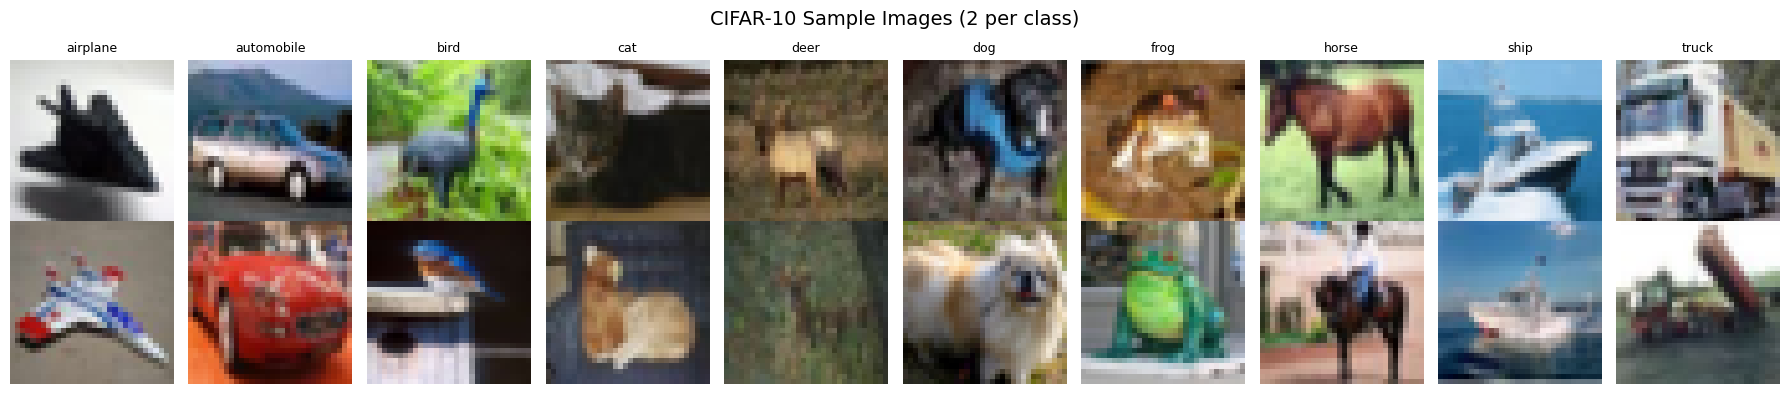

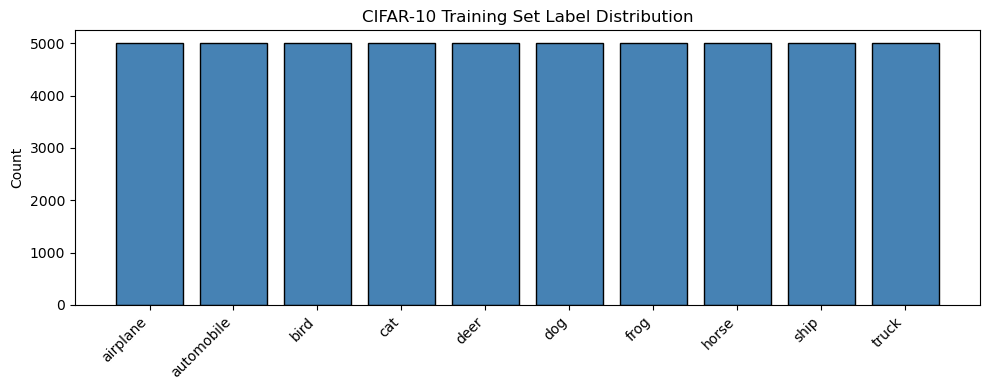

In [3]:
def unnormalize(img):
    """Reverse the normalization for display."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1)

# Show sample images from each class
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
# Find examples of each class
class_examples = {i: [] for i in range(10)}
for img, label in train_dataset:
    if len(class_examples[label]) < 2:
        class_examples[label].append(img)
    if all(len(v) >= 2 for v in class_examples.values()):
        break

for cls_idx in range(10):
    for row in range(2):
        ax = axes[row, cls_idx]
        img = unnormalize(class_examples[cls_idx][row])
        ax.imshow(img.permute(1, 2, 0).numpy())  # CHW -> HWC for matplotlib
        if row == 0:
            ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
        ax.axis('off')

plt.suptitle('CIFAR-10 Sample Images (2 per class)', fontsize=14)
plt.tight_layout()
plt.show()

# Label distribution
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
plt.figure(figsize=(10, 4))
plt.bar(range(10), [labels.count(i) for i in range(10)], color='steelblue', edgecolor='black')
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha='right')
plt.ylabel('Count')
plt.title('CIFAR-10 Training Set Label Distribution')
plt.tight_layout()
plt.show()

## Step 2: Build the Fully Connected Network

We use a larger network than our MNIST model since CIFAR-10 is harder and has more input features:

```
Input (3 x 32 x 32 = 3072 pixels)
  -> Flatten
  -> Linear(3072, 512) + ReLU + Dropout(0.3)
  -> Linear(512, 256) + ReLU + Dropout(0.3)
  -> Linear(256, 128) + ReLU + Dropout(0.3)
  -> Linear(128, 10)
```

### Why Dropout?

**Dropout** is a regularization technique that randomly sets a fraction of neuron outputs to zero during training. This prevents the network from relying too heavily on any single neuron and encourages redundant representations. During evaluation, dropout is disabled and all neurons contribute.

### The parameter explosion problem

Note the first layer alone: 3072 inputs x 512 outputs = **1.57 million parameters** (plus biases). This is a key limitation of fully connected networks for images -- they need too many parameters and still cannot capture spatial structure.

In [4]:
class CIFAR10Net(nn.Module):
    """Fully connected network for CIFAR-10 classification."""
    
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                # 3x32x32 -> 3072
            nn.Linear(3 * 32 * 32, 512), # 3072 -> 512
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),         # 512 -> 256
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),         # 256 -> 128
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),          # 128 -> 10 classes
        )
    
    def forward(self, x):
        return self.net(x)

model = CIFAR10Net().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Show parameter count per layer
print("\nParameters per layer:")
for name, param in model.named_parameters():
    print(f"  {name:30s} {str(param.shape):20s} {param.numel():>10,}")

Model architecture:
CIFAR10Net(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters:     1,738,890
Trainable parameters: 1,738,890

Parameters per layer:
  net.1.weight                   torch.Size([512, 3072])  1,572,864
  net.1.bias                     torch.Size([512])           512
  net.4.weight                   torch.Size([256, 512])    131,072
  net.4.bias                     torch.Size([256])           256
  net.7.weight                   torch.Size([128, 256])     32,768
  net.7.bias                     torch.Size([128])           128


## Step 3: Define Loss and Optimizer

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


## Step 4: Training Loop

In [6]:
def evaluate(model, loader, loss_fn, device):
    """Evaluate the model on a dataset."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_seen += labels.size(0)
    
    return total_loss / total_seen, total_correct / total_seen

In [ ]:
# Training loop
train_losses = []
test_losses = []
train_accs = []
test_accs = []

print(f"Training on {device} for {EPOCHS} epochs...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | {'Time':>6}")
print("-" * 65)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_seen = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        logits = model(images)
        loss = loss_fn(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        running_seen += labels.size(0)
    
    train_loss = running_loss / running_seen
    train_acc = running_correct / running_seen
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    elapsed = time.time() - epoch_start
    print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:8.2%} | {test_loss:9.4f} | {test_acc:7.2%} | {elapsed:5.1f}s")

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s")
print(f"Final test accuracy: {test_accs[-1]:.2%}")

Training on mps for 20 epochs...
Epoch | Train Loss | Train Acc | Test Loss | Test Acc |   Time
-----------------------------------------------------------------
    1 |     1.8170 |   35.15% |    1.6091 |  43.67% |   6.9s
    2 |     1.6501 |   41.95% |    1.4986 |  47.01% |   6.4s
    3 |     1.5755 |   44.73% |    1.4881 |  47.59% |   7.2s
    4 |     1.5293 |   46.35% |    1.4407 |  49.54% |   7.0s
    5 |     1.4874 |   47.75% |    1.4257 |  50.09% |   6.5s
    6 |     1.4530 |   48.99% |    1.4147 |  49.29% |   6.5s


## Step 5: Visualize Training Progress

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss', markersize=3)
ax1.plot(epochs_range, test_losses, 'r-o', label='Test Loss', markersize=3)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a * 100 for a in train_accs], 'b-o', label='Train Accuracy', markersize=3)
ax2.plot(epochs_range, [a * 100 for a in test_accs], 'r-o', label='Test Accuracy', markersize=3)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Highlight the overfitting gap
gap = train_accs[-1] - test_accs[-1]
print(f"\nOverfitting gap (train - test accuracy): {gap:.2%}")
if gap > 0.1:
    print("Significant overfitting detected! The model memorizes training data but doesn't generalize well.")
    print("This is a common issue with fully connected networks on complex image datasets.")

## Step 6: Analyze Results per Class

In [ ]:
# Get all predictions
model.eval()
all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
        all_images.append(images)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_images = torch.cat(all_images)

# Per-class accuracy
print("Per-class accuracy:")
print("-" * 35)
class_accs = []
for i in range(10):
    mask = all_labels == i
    class_acc = (all_preds[mask] == all_labels[mask]).float().mean().item()
    class_accs.append(class_acc)
    print(f"  {CLASS_NAMES[i]:12s}: {class_acc:.2%}")

# Bar chart of per-class accuracy
plt.figure(figsize=(10, 5))
colors = ['green' if a > 0.6 else 'orange' if a > 0.4 else 'red' for a in class_accs]
plt.bar(range(10), [a * 100 for a in class_accs], color=colors, edgecolor='black')
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Test Accuracy')
plt.axhline(y=np.mean(class_accs) * 100, color='blue', linestyle='--', label=f'Mean: {np.mean(class_accs):.1%}')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Visualize Predictions

In [ ]:
# Show correct and incorrect predictions
correct_mask = all_preds == all_labels
incorrect_idx = torch.where(~correct_mask)[0]

fig, axes = plt.subplots(2, 8, figsize=(18, 5))

# Top row: correct predictions
correct_idx = torch.where(correct_mask)[0]
for i in range(8):
    ax = axes[0, i]
    idx = correct_idx[i * 100].item()  # Spread out the examples
    img = unnormalize(all_images[idx])
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f'{CLASS_NAMES[all_preds[idx]]}', color='green', fontweight='bold', fontsize=9)
    ax.axis('off')

# Bottom row: incorrect predictions
for i in range(min(8, len(incorrect_idx))):
    ax = axes[1, i]
    idx = incorrect_idx[i * 50].item() if i * 50 < len(incorrect_idx) else incorrect_idx[i].item()
    img = unnormalize(all_images[idx])
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f'{CLASS_NAMES[all_preds[idx]]}\n(true: {CLASS_NAMES[all_labels[idx]]})',
                 color='red', fontweight='bold', fontsize=8)
    ax.axis('off')

axes[0, 0].set_ylabel('Correct', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Wrong', fontsize=12, fontweight='bold')
plt.suptitle('Model Predictions on CIFAR-10 Test Set', fontsize=14)
plt.tight_layout()
plt.show()

## Step 8: Confusion Matrix

In [ ]:
# Confusion matrix
confusion = torch.zeros(10, 10, dtype=torch.int64)
for pred, true in zip(all_preds, all_labels):
    confusion[true, pred] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion, cmap='Blues')

for i in range(10):
    for j in range(10):
        color = 'white' if confusion[i, j] > confusion.max() / 2 else 'black'
        ax.text(j, i, f'{confusion[i, j]}', ha='center', va='center', color=color, fontsize=8)

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
plt.colorbar(im)
plt.tight_layout()
plt.show()

# Most common confusions
print("\nMost common confusions (off-diagonal):")
conf_copy = confusion.clone()
conf_copy.fill_diagonal_(0)
for _ in range(5):
    idx = conf_copy.argmax()
    true_cls = idx // 10
    pred_cls = idx % 10
    count = conf_copy[true_cls, pred_cls].item()
    print(f"  {CLASS_NAMES[true_cls]:>10} misclassified as {CLASS_NAMES[pred_cls]:<10}: {count} times")
    conf_copy[true_cls, pred_cls] = 0

## Summary and Discussion

### Results

The fully connected network achieves approximately **50-55% accuracy** on CIFAR-10 test set. While this is much better than random guessing (10%), it is far from state-of-the-art.

### Why does the fully connected network struggle?

1. **No spatial awareness**: Flattening the image destroys the 2D structure. A pixel's neighbors carry important information (edges, textures), but the FC network treats every pixel independently.

2. **Parameter inefficiency**: The first layer alone has ~1.5M parameters. Despite this, the network cannot learn the right features because it lacks inductive bias for spatial data.

3. **No translation invariance**: If a cat appears in the top-left corner during training, the network cannot recognize it in the bottom-right corner at test time.

4. **Overfitting**: The large number of parameters relative to the dataset size makes the model prone to memorizing the training data.

### The solution: Convolutional Neural Networks

In the next tutorial, we will build a **CNN** that addresses all these issues:
- **Convolution layers** scan the image with small filters, preserving spatial structure
- **Parameter sharing** dramatically reduces the number of parameters
- **Pooling layers** provide translation invariance

A CNN with fewer total parameters can achieve **75%+** accuracy on CIFAR-10!

### Exercises:

1. **Remove dropout**: How much worse does overfitting become?
2. **Add more layers**: Does a deeper FC network help? Try adding layers with 1024 and 512 neurons.
3. **Data augmentation**: Add `transforms.RandomHorizontalFlip()` and `transforms.RandomCrop(32, padding=4)` to the training transform. Does it help?
4. **Learning rate scheduling**: Add `torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)` and call `scheduler.step()` after each epoch.